In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns                                         #импортируем все нужные нам библиотеки
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error,r2_score


In [3]:
names_df = pd.read_csv("csgoml/name_conversion_table.csv")

case_df = names_df[names_df["decoded name"].str.contains("Case",na=False)&
                   (~names_df['decoded name'].str.contains('Souvenir|Capsule|Package|Hardened|Key', na=False))]      #получили датафрйем названий нужных для нас предмето,чью цену мы будем предсказывать

In [4]:
items_path = 'csgoml/items' 

all_dfs = [] 

for index, row in case_df.iterrows():
    encoded = row['URL encoded name']
    decoded = row['decoded name']
    file_path = os.path.join(items_path, f"{encoded}.csv")
    
    if os.path.exists(file_path):
        temp_df = pd.read_csv(file_path)                                            #взяли нужные нам имена и получили данные от общего датасета 
        temp_df['case_name'] = decoded
        all_dfs.append(temp_df)
    else:
        print(f"Внимание: Файл для {decoded} не найден по пути {file_path}")
final_df = pd.concat(all_dfs, ignore_index=True)



In [5]:
# Преобразуем unix-время в понятные признаки для модели
final_df["date_clean"] = pd.to_datetime(final_df["date"], format='%b %d %Y %H: +0' )
final_df["month"] = final_df["date_clean"].dt.month 
final_df["year"] = final_df["date_clean"].dt.year
final_df['day_of_week'] = final_df['date_clean'].dt.dayofweek                                               #создаем нужные нам признаки,преобразовываем дату чтобы модель понимала ее

release_dates = final_df.groupby('case_name')['unix timestamp'].min()
final_df['release_unix'] = final_df['case_name'].map(release_dates)
# Создаем признак "дней с момента выхода кейса" — это критически важно для прогноза цены
final_df['days_since_release'] = (final_df['unix timestamp'] - final_df['release_unix']) / 86400

final_df = final_df.sort_values(["case_name","unix timestamp"])
#final_df["lags_30day"] = final_df.groupby("case_name")["price"].shift(30)        

 заккоментировали эту строчку,так как произвел анализ и если создать этот признак  модель будет смотреть в 90 процентах только на этот признак и предсказания будут зависить от него
 и в самой модели будет мало толку


In [ ]:
limit = final_df['quantity'].quantile(0.85) # Берем топ 15% самых массовых продаж
final_df['is_active_drop'] = (final_df['quantity'] > limit).astype(int)
final_df = final_df.drop(columns=["date","date_clean"])
final_df = final_df.dropna().reset_index(drop=True)


In [62]:
final_df = final_df.sort_values("unix timestamp")
split_index = int(len(final_df)*0.8)
train_df = final_df.iloc[:split_index]
test_df = final_df.iloc[split_index:]
X_train = train_df.drop(columns=["price"])
y_train = train_df["price"]                                      #так как работаем с датами и предсказнием цен, для того чтобы не было утечки данных делим датасет таким образом а не используем train_test_split

X_test = test_df.drop(columns=["price"])
y_test = test_df["price"]
print(train_df.shape,test_df.shape)

(426624, 10) (106656, 10)


In [17]:
cat_features = ["case_name"]
catboost = CatBoostRegressor(iterations=1000,learning_rate=0.1,
                             loss_function="MAE",
                             verbose=100,eval_metric="MAE")        #обучаем модель с помощью catboost
catboost.fit(X_train,y_train,cat_features=cat_features)

0:	learn: 4.7377478	total: 126ms	remaining: 2m 6s
100:	learn: 0.4907267	total: 12.3s	remaining: 1m 49s
200:	learn: 0.3854330	total: 24.7s	remaining: 1m 38s
300:	learn: 0.3495474	total: 37.2s	remaining: 1m 26s
400:	learn: 0.3245560	total: 50s	remaining: 1m 14s
500:	learn: 0.3031099	total: 1m 2s	remaining: 1m 2s
600:	learn: 0.2890652	total: 1m 14s	remaining: 49.8s
700:	learn: 0.2793079	total: 1m 27s	remaining: 37.3s
800:	learn: 0.2719080	total: 1m 39s	remaining: 24.8s
900:	learn: 0.2645970	total: 1m 52s	remaining: 12.4s
999:	learn: 0.2591122	total: 2m 5s	remaining: 0us


In [ ]:
y_pred = catboost.predict(X_test)
mae = mean_absolute_error(y_test,y_pred)
mape = mean_absolute_percentage_error(y_test,y_pred)
r2 = r2_score(y_test, y_pred)                                          
print(f"метрика mae: {mae:.4f}, метрика mape: {mape:.4f}, коэффицент детерминации: {r2:.4f}")

метрика mae: 0.8510, метрика mape: 0.2699, коэффицент детерминации: 0.9754


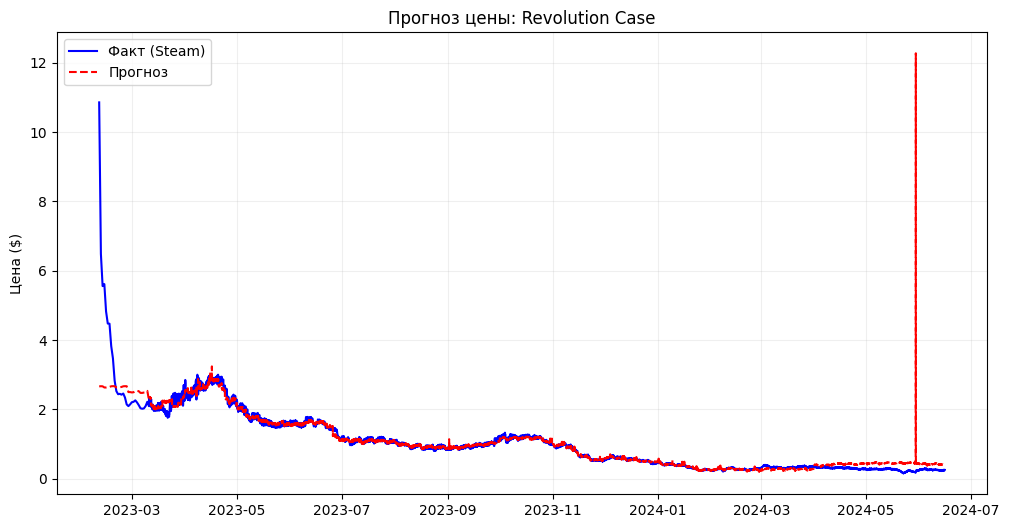

In [75]:
case_name = "Revolution Case" #взяли один рандомный кейс чтобы показать как выглядит наша модель
case_df = final_df[final_df['case_name'] == case_name].copy() 
case_df['date'] = pd.to_datetime(case_df['unix timestamp'], unit='s')
case_df = case_df.sort_values('date')


X_case = case_df.drop(columns=['price', 'date'])
case_preds = catboost.predict(X_case) 


plt.figure(figsize=(12, 6))
plt.plot(case_df['date'], case_df['price'], label='Факт (Steam)', color='blue')
plt.plot(case_df['date'], case_preds, label='Прогноз', color='red', linestyle='--')

plt.title(f'Прогноз цены: {case_name}')
plt.ylabel('Цена ($)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

Анализ результатов: Модель CatBoost показала R² =0.9754. Высокое значение MAPE (26%) объясняется резкими скачками цен в моменты обновлений игры и техническими аномалиями в данных за июнь 2024 года. Модель хорошо улавливает общие тренды, но консервативна в прогнозировании аномальных пиков.

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
#у xgboost есть другой способ работы с категоиальными значениями,но у него он плохо сработал и выдал ужасные метрики
#Обучаем его на ВСЕХ названиях кейсов (из final_df), 
# чтобы он знал все возможные варианты
final_df['case_name'] = le.fit_transform(final_df['case_name'].astype(str))


train_df = final_df.iloc[:split_index]
test_df = final_df.iloc[split_index:]

X_train = train_df.drop(columns=["price"])
y_train = train_df["price"]
X_test = test_df.drop(columns=["price"])
y_test = test_df["price"]
print(train_df.shape,test_df.shape)

(426624, 10) (106656, 10)


In [ ]:
xgboost = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=6, 
    objective="reg:squarederror",
    
)
xgboost.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
y_pred_xg = xgboost.predict(X_test)
mae = mean_absolute_error(y_test,y_pred_xg)
mape = mean_absolute_percentage_error(y_test,y_pred_xg)
r2 = r2_score(y_test, y_pred_xg)                                           #получаем нужные нам метрики, метрика mape получилась настолько большая так как в игре бывают обновления,которые резко вызывают колебание цены
print(f"метрика mae: {mae:.4f}, метрика mape: {mape:.4f}, коэффицент детерминации: {r2:.4f}") 

метрика mae: 4.0549, метрика mape: 1.6751, коэффицент детерминации: -0.2156


Так как модель xgboost выдала плохой результат,мы выбираем модель catboost

In [44]:
catboost.save_model("best_model.cbm")